## Instructions

Use NLP technologies to extract entities from medical notes data. To receive full credit, your project should yield Spacy, SciSpacy and Medspacy https://github.com/medspacy/medspacy extracted entities, word2vec, and tuned t-SNE plots for all three Python libraries. Compare and contrast the results you achieve. The incorporation of DisplaCy is encouraged but not required. See the rubric below for more information.

How to get medical notes: MIMIC NOTEEVENTS Table contains different kinds of medical reports. It is a file over >1 GB in size, so it might take 30 mins for you to load it in. We have provided python code that can help you extract a set of medical notes from NOTEEVENTS table. The example here shows how to extract discharge notes for patients diagnosed with ICD9 code 430 (Subarachnoid hemorrhage), which is also available with our lecture series resources. 

The NLP assignment features t-SNE, and you may run into a lot of confusion working with it for the first time. So please have a look at How to Use t-SNE Effectively. Tune your t-SNE plots. The addition of UMAP is encouraged but not required.

## Bonus 1 pt

To receive a bonus point for this assignment, you can introduce a new NLP tool such as cTakes, BERT, BlueBERT, ClinicalBERT, BioBERT or BioClinicalBERT. and apply it on MIMIC dataset.

> Please highlight any work intended for bonus credit.

## Submission

1. Your Python code file as a Jupyter notebook (.ipynb) -- with executed code blocks.
2. For each of spaCy, scispaCy and medspaCy, perform the entity extraction, word2vec and a tuned t-SNE. Show each of these results for each model in your slide presentation (not just a t-SNE). The use of displaCy is encouraged although not required. You are also encouraged to try UMAP in addition to (not instead of) t-SNE. Compare and contrast your results.
3. Slides (.pptx or .pdf), including your interpretation and comparison of your results.

# **Download Data**

In [81]:
"""
First download the data into a dataframe.
"""
import pandas as pd
from google.cloud import bigquery

PROJECT_ID = "project-eba4607b-9314-4a56-97d"
client = bigquery.Client(project=PROJECT_ID)

# Generalized query function
job_config = bigquery.QueryJobConfig(
    maximum_bytes_billed=10 * 1024**3  # 10 GB limit
)

def run_query(sql: str) -> pd.DataFrame:
    """Run a SQL query against BigQuery and return a pandas DataFrame."""
    return client.query(sql, job_config=job_config).to_dataframe()

# View all datasets I have access to
datasets = list(client.list_datasets(project="physionet-data"))
for d in datasets:
    print(d.dataset_id)

mimiciii_clinical
mimiciii_derived
mimiciii_notes
mimiciii_notes_derived
mimiciv_3_1_derived
mimiciv_3_1_hosp
mimiciv_3_1_icu


In [82]:

# View counts for specific diagnoses
# ^ Using BigQuery console to reference table and column names
# ^ Using mimic documentation for table relationship reference
# ^ https://mimic.mit.edu/docs/iii/tables/admissions.html
# ^ https://mimic.mit.edu/docs/iii/tables/diagnoses_icd.html

import os, pickle

P = "diagnoses_count_df.pkl"

if os.path.exists(P):
    diagnoses_count_df = pickle.load(open(P, "rb"))
else:
    diagnoses_count_df = run_query("""
        SELECT 
            count(d.icd9_code) as occurences,
            d.icd9_code as icd9_code,
            dx.long_title as diagnosis_name
        FROM `physionet-data.mimiciii_clinical.diagnoses_icd` d
        LEFT JOIN `physionet-data.mimiciii_clinical.d_icd_diagnoses` dx on d.icd9_code = dx.icd9_code
        GROUP BY d.icd9_code, dx.long_title
    """)

    pickle.dump(diagnoses_count_df, open(P, "wb"))

In [83]:
# Investigate what cohort I want to use, being mindful of data available
diagnoses_count_df = diagnoses_count_df.sort_values(by="occurences", ascending=False)
diagnoses_count_df.head(50)

,occurences,icd9_code,diagnosis_name
21,20703,4019,Unspecified essential hypertension
38,13111,4280,"Congestive heart failure, unspecified"
9,12891,42731,Atrial fibrillation
6,12429,41401,Coronary atherosclerosis of native coronary ar...
25,9119,5849,"Acute kidney failure, unspecified"
129,9058,25000,Diabetes mellitus without mention of complicat...
7,8690,2724,Other and unspecified hyperlipidemia
169,7497,51881,Acute respiratory failure
13,6555,5990,"Urinary tract infection, site not specified"
132,6326,53081,Esophageal reflux


In [84]:
""" 
Based on the results, I choose to investigate the cohort of patients who 
suffered from "Hyperpotassemia".

This condition is unknown to me, so I am curious of what entities 
and other information will be revealed.
"""

# ^ noteevents table documentation:
# ^ https://mimic.mit.edu/docs/iii/tables/noteevents.html

import os, pickle

P = "noteevents_df.pkl"

if os.path.exists(P):
    noteevents_df = pickle.load(open(P, "rb"))
else:
    # # Hyperlipidemia
    # noteevents_df = run_query("""
    #     SELECT
    #         n.text
    #     FROM `physionet-data.mimiciii_notes.noteevents` n
    #     LEFT JOIN `physionet-data.mimiciii_clinical.diagnoses_icd` d on n.hadm_id = d.hadm_id
    #     WHERE d.icd9_code = '2724'
    #     LIMIT 100000
    # """)

    # hyperpotassemia
    noteevents_df = run_query("""
        SELECT
            n.text
        FROM `physionet-data.mimiciii_notes.noteevents` n
        LEFT JOIN `physionet-data.mimiciii_clinical.diagnoses_icd` d on n.hadm_id = d.hadm_id
        WHERE d.icd9_code = '2767'
        LIMIT 100000
    """)

    pickle.dump(noteevents_df, open(P, "wb"))

In [85]:
noteevents_df.info()
noteevents_df

<class 'pandas.DataFrame'>
RangeIndex: 73973 entries, 0 to 73972
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    73973 non-null  str  
dtypes: str(1)
memory usage: 184.0 MB


,text
0,Normal sinus rhythm. Axis 0 degrees. Tracing i...
1,Sinus rhythm. Borderline P-R interval prolong...
2,Sinus rhythm. Low limb lead voltage. Q-T int...
3,Sinus rhythm with borderline 1st degree A-V bl...
4,Sinus rhythm. Non-specific ST-T wave changes....
...,...
73968,"TITLE:\n Chief Complaint: Headache, chemothe..."
73969,TITLE:\n Chief Complaint:\n 24 Hour Events...
73970,"Chief Complaint: HTN, abd pain\n HPI:\n M..."
73971,Chief Complaint:\n Patient's Name: [**Known ...


# **t-SNE Functions**

In [86]:
"""
Define tuning t-SNE plot
"""

import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def tune_tsne_plot(model, words, plot_perplexity=50, plot_max_iter=1000, preTrained=False, entity_labels=None, ax=None):
    "Creates a TSNE model and plots it, colored by entity type if entity_labels is given"
    labels = []
    tokens = []

    for word in words:
        if preTrained:
            tokens.append(model[word])
        else:
            tokens.append(model.wv[word])
        labels.append(word)

    tokens = np.array(tokens)
    tsne_model = TSNE(perplexity=plot_perplexity, early_exaggeration=12, n_components=2, init='pca', max_iter=plot_max_iter, random_state=23, metric="cosine")
    new_values = tsne_model.fit_transform(tokens)

    x = new_values[:, 0]
    y = new_values[:, 1]

    # Map each word to its entity type, e.g. "PERSON", "ORG", "GPE"
    if entity_labels is not None:
        types = [entity_labels.get(w, "UNKNOWN") for w in labels]
    else:
        types = ["ALL"] * len(labels)

    unique_types = sorted(set(types))
    cmap = plt.get_cmap("tab20")
    colors = {t: cmap(i % 20) for i, t in enumerate(unique_types)}

    if ax is None:
        _, ax = plt.subplots(figsize=(16, 16))
    
    for i in range(len(x)):
        c = colors[types[i]]
        ax.scatter(x[i], y[i], color=c, s=10)
        ax.annotate(labels[i],
                    xy=(x[i], y[i]),
                    xytext=(5, 2),
                    textcoords='offset points',
                    ha='right',
                    va='bottom',
                    color=c,
                    fontsize=6)

    ax.set_title(f"perplexity={plot_perplexity}, max_iter={plot_max_iter}")

    # Legend with one entry per entity type
    handles = [Line2D([0], [0], marker='o', linestyle='', color=colors[t], label=t)
               for t in unique_types]
    
    return handles


In [87]:
"""
Define t-SNE plot
"""

import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def tsne_plot(model, words, plot_perplexity=25, plot_max_iter=1500, plot_name="", preTrained=False, entity_labels=None):
    "Creates a TSNE model and plots it, colored by entity type if entity_labels is given"
    labels = []
    tokens = []

    for word in words:
        if preTrained:
            tokens.append(model[word])
        else:
            tokens.append(model.wv[word])
        labels.append(word)

    tokens = np.array(tokens)
    tsne_model = TSNE(perplexity=plot_perplexity, early_exaggeration=12, n_components=2, init='pca', max_iter=plot_max_iter, random_state=23, metric="cosine")
    new_values = tsne_model.fit_transform(tokens)

    x = new_values[:, 0]
    y = new_values[:, 1]

    # Map each word to its entity type, e.g. "PERSON", "ORG", "GPE"
    if entity_labels is not None:
        types = [entity_labels.get(w, "UNKNOWN") for w in labels]
    else:
        types = ["ALL"] * len(labels)

    unique_types = sorted(set(types))
    cmap = plt.get_cmap("tab20")
    colors = {t: cmap(i % 20) for i, t in enumerate(unique_types)}

    plt.figure(figsize=(16, 16))
    for i in range(len(x)):
        c = colors[types[i]]
        plt.scatter(x[i], y[i], color=c)
        plt.annotate(labels[i],
                     xy=(x[i], y[i]),
                     xytext=(5, 2),
                     textcoords='offset points',
                     ha='right',
                     va='bottom',
                     color=c)

    # Legend with one entry per entity type
    handles = [Line2D([0], [0], marker='o', linestyle='', color=colors[t], label=t)
               for t in unique_types]
    plt.legend(handles=handles, title="Entity type", loc="upper left")
    plt.savefig(plot_name + '.png')
    plt.show()


# **spaCy**

In [88]:
"""
Build corpus of entities and a dict entity text and label.
"""

# ! pip install -U spacy
# ! python -m spacy download en_core_web_sm
import spacy
from spacy import displacy
import os, pickle
from tqdm.auto import tqdm

PE = "spacy_entities.pkl"
PC = "spacy_corpus_entities.pkl"
SAMPLE_FRAC = 0.2
MAX_CHARS = 20000

if os.path.exists(PE) and os.path.exists(PC):
    spacy_entities = pickle.load(open(PE, "rb"))
    spacy_corpus = pickle.load(open(PC, "rb"))
else:
    nlp = spacy.load("en_core_web_sm", exclude=["parser", "lemmatizer", "attribute_ruler", "tagger"]) # Drop unnecessary components to save processing time

    text = noteevents_df['text'].dropna().sample(frac=SAMPLE_FRAC, random_state=42)
    text = text.str.slice(0, MAX_CHARS)

    spacy_entities = {}
    spacy_corpus = []

    for doc in tqdm(nlp.pipe(text, batch_size=32, n_process=4), total=len(text), desc="Extracting entities"):
        ents = [e.text.lower() for e in doc.ents]
        spacy_corpus.append(ents)

        for entity in doc.ents:
            spacy_entities.setdefault(entity.text.lower(), entity.label_)

    pickle.dump(spacy_entities, open(PE, "wb"))
    pickle.dump(spacy_corpus, open(PC, "wb"))

In [89]:
from collections import Counter
import pandas as pd

corpus, ents = spacy_corpus, spacy_entities

counts = Counter(e for note in corpus for e in note)
top30 = [(" ".join(e.split()), ents.get(e, "UNKNOWN"), c) for e, c in counts.most_common(30)]

display(pd.DataFrame(top30, columns=["Entity", "Type", "Mentions"], index=range(1, len(top30) + 1)))


,Entity,Type,Mentions
1,2,CARDINAL,9858
2,1,CARDINAL,9323
3,response,ORG,7761
4,3,CARDINAL,6109
5,icu,ORG,5479
6,today,DATE,5087
7,5,CARDINAL,4694
8,bp,ORG,4172
9,po,ORG,4142
10,4,CARDINAL,3994


In [90]:
"""
Train word2vec on the corpus
"""

from gensim.models import Word2Vec

# Removing these entities because it filled the plot with numbers
# skip = {"CARDINAL", "PERCENT", "QUANTITY", "TIME", "DATE", "ORDINAL", "MONEY"}
skip = []

corpus_filtered = [
    [e for e in note if spacy_entities.get(e, "") not in skip]
    for note in spacy_corpus
]

model = Word2Vec(corpus_filtered, min_count=5)

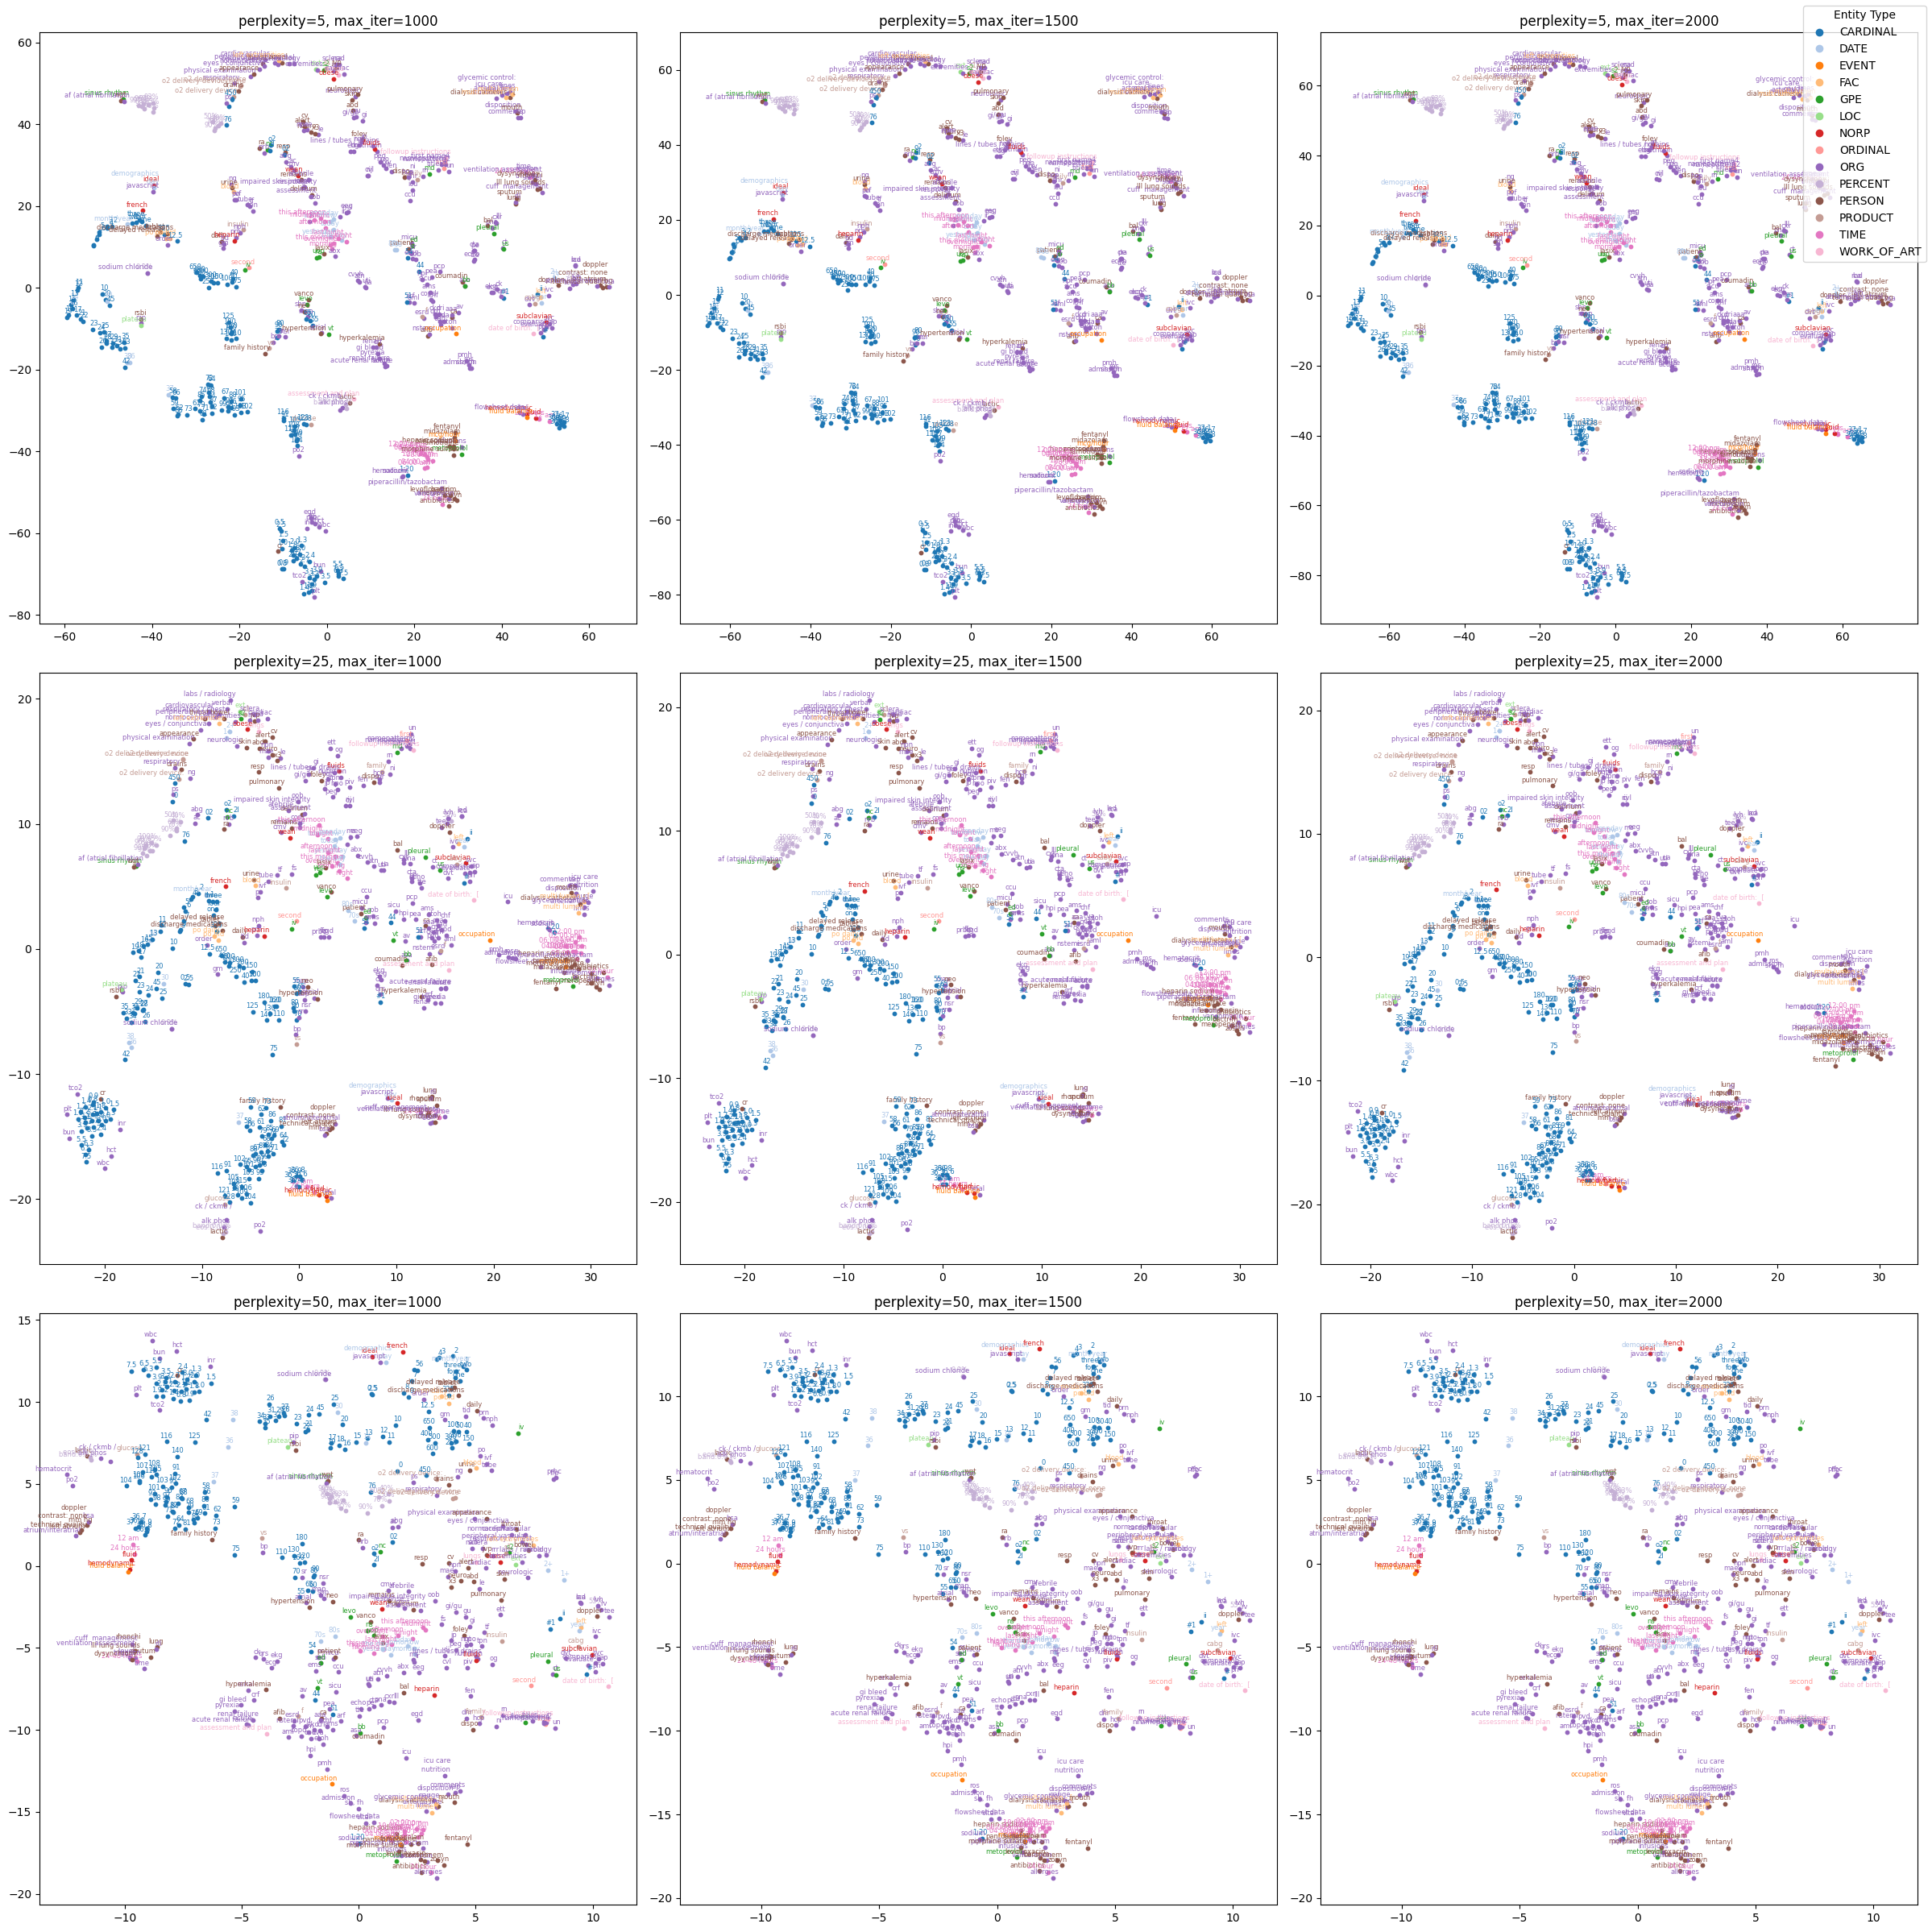

In [91]:
"""
Print plot for the corpus
"""
# Only using top 500 entities, more than that would compromise the value of the plots
vocabs = list(model.wv.key_to_index.keys())[:500]
new_v = np.array(vocabs)

fig, axes = plt.subplots(3, 3, figsize=(24, 24))

handles = tune_tsne_plot(model, new_v, 5, 1000, entity_labels=spacy_entities, ax=axes[0,0])
handles = tune_tsne_plot(model, new_v, 5, 1500, entity_labels=spacy_entities, ax=axes[0,1])
handles = tune_tsne_plot(model, new_v, 5, 2000, entity_labels=spacy_entities, ax=axes[0,2])

handles = tune_tsne_plot(model, new_v, 25, 1000, entity_labels=spacy_entities, ax=axes[1,0])
handles = tune_tsne_plot(model, new_v, 25, 1500, entity_labels=spacy_entities, ax=axes[1,1])
handles = tune_tsne_plot(model, new_v, 25, 2000, entity_labels=spacy_entities, ax=axes[1,2])

handles = tune_tsne_plot(model, new_v, 50, 1000, entity_labels=spacy_entities, ax=axes[2,0])
handles = tune_tsne_plot(model, new_v, 50, 1500, entity_labels=spacy_entities, ax=axes[2,1])
handles = tune_tsne_plot(model, new_v, 50, 2000, entity_labels=spacy_entities, ax=axes[2,2])

fig.legend(handles=handles, title="Entity Type", loc="upper right")
plt.tight_layout()
plt.savefig('spacy_tsne_tuning.png')
plt.show()

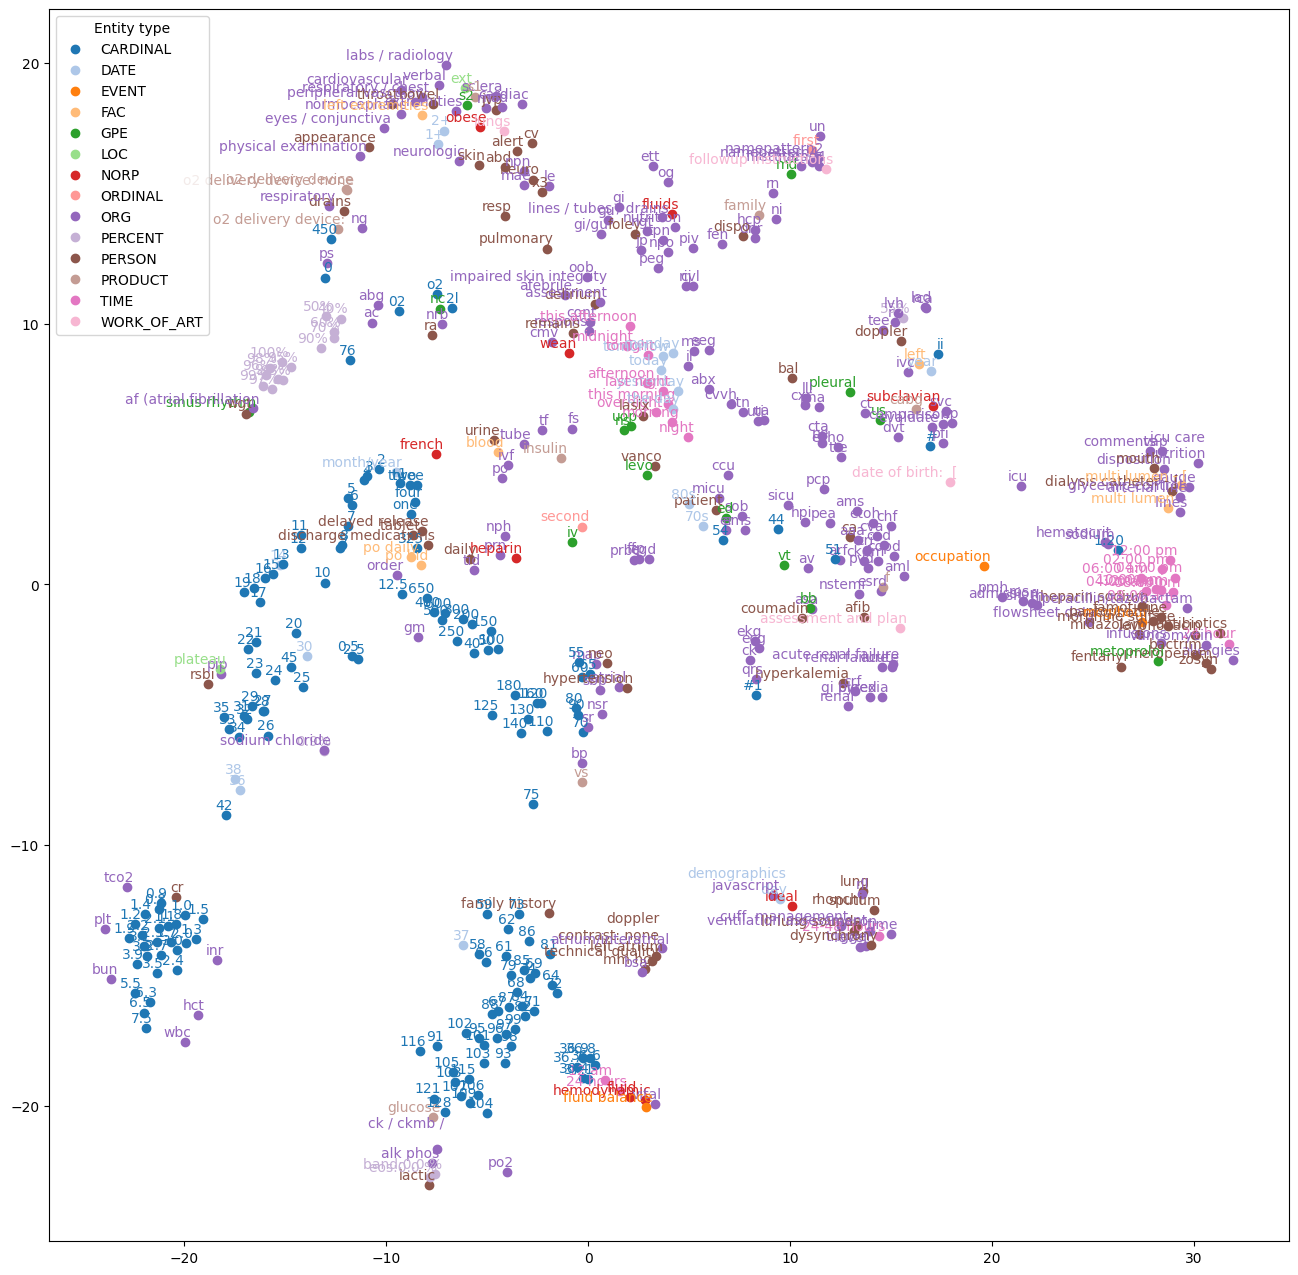

In [92]:
tsne_plot(model, new_v, 25, 1000, "spacy_tuned_tsne", entity_labels=spacy_entities)

# **scispaCy**

In [93]:
"""
Build corpus of entities and a dict entity text and label.
"""

import os, pickle
from tqdm.auto import tqdm
import scispacy
import spacy

PE = "scispacy_entities.pkl"
PC = "scispacy_corpus_entities.pkl"
SAMPLE_FRAC = 0.2
MAX_CHARS = 20000

if os.path.exists(PE) and os.path.exists(PC):
    scispacy_entities = pickle.load(open(PE, "rb"))
    scispacy_corpus = pickle.load(open(PC, "rb"))
else:
    nlp = spacy.load("en_ner_bc5cdr_md", exclude=["parser", "lemmatizer", "attribute_ruler", "tagger"])

    text = noteevents_df['text'].dropna().sample(frac=SAMPLE_FRAC, random_state=42)
    text = text.str.slice(0, MAX_CHARS)

    scispacy_entities = {}
    scispacy_corpus = []

    for doc in tqdm(nlp.pipe(text, batch_size=32, n_process=4), total=len(text), desc="Extracting entities"):
        ents = [e.text.lower() for e in doc.ents]
        scispacy_corpus.append(ents)

        for entity in doc.ents:
            scispacy_entities.setdefault(entity.text.lower(), entity.label_)

    pickle.dump(scispacy_entities, open(PE, "wb"))
    pickle.dump(scispacy_corpus, open(PC, "wb"))

In [94]:
from collections import Counter
import pandas as pd

corpus, ents = scispacy_corpus, scispacy_entities

counts = Counter(e for note in corpus for e in note)
top30 = [(" ".join(e.split()), ents.get(e, "UNKNOWN"), c) for e, c in counts.most_common(30)]

display(pd.DataFrame(top30, columns=["Entity", "Type", "Mentions"], index=range(1, len(top30) + 1)))


,Entity,Type,Mentions
1,pain,DISEASE,6471
2,pt,CHEMICAL,3544
3,lasix,CHEMICAL,3281
4,edema,DISEASE,3260
5,heparin,CHEMICAL,3202
6,hypotension,DISEASE,3194
7,allergies,DISEASE,3046
8,fio2,CHEMICAL,2941
9,o2,CHEMICAL,2929
10,ng,CHEMICAL,2928


In [95]:
"""
Train word2vec on the corpus
"""

from gensim.models import Word2Vec

# Removing these entities because it filled the plot with numbers
# skip = {"CARDINAL", "PERCENT", "QUANTITY", "TIME", "DATE", "ORDINAL", "MONEY"}
skip = []

corpus_filtered = [
    [e for e in note if scispacy_entities.get(e, "") not in skip]
    for note in scispacy_corpus
]

model = Word2Vec(corpus_filtered, min_count=5)

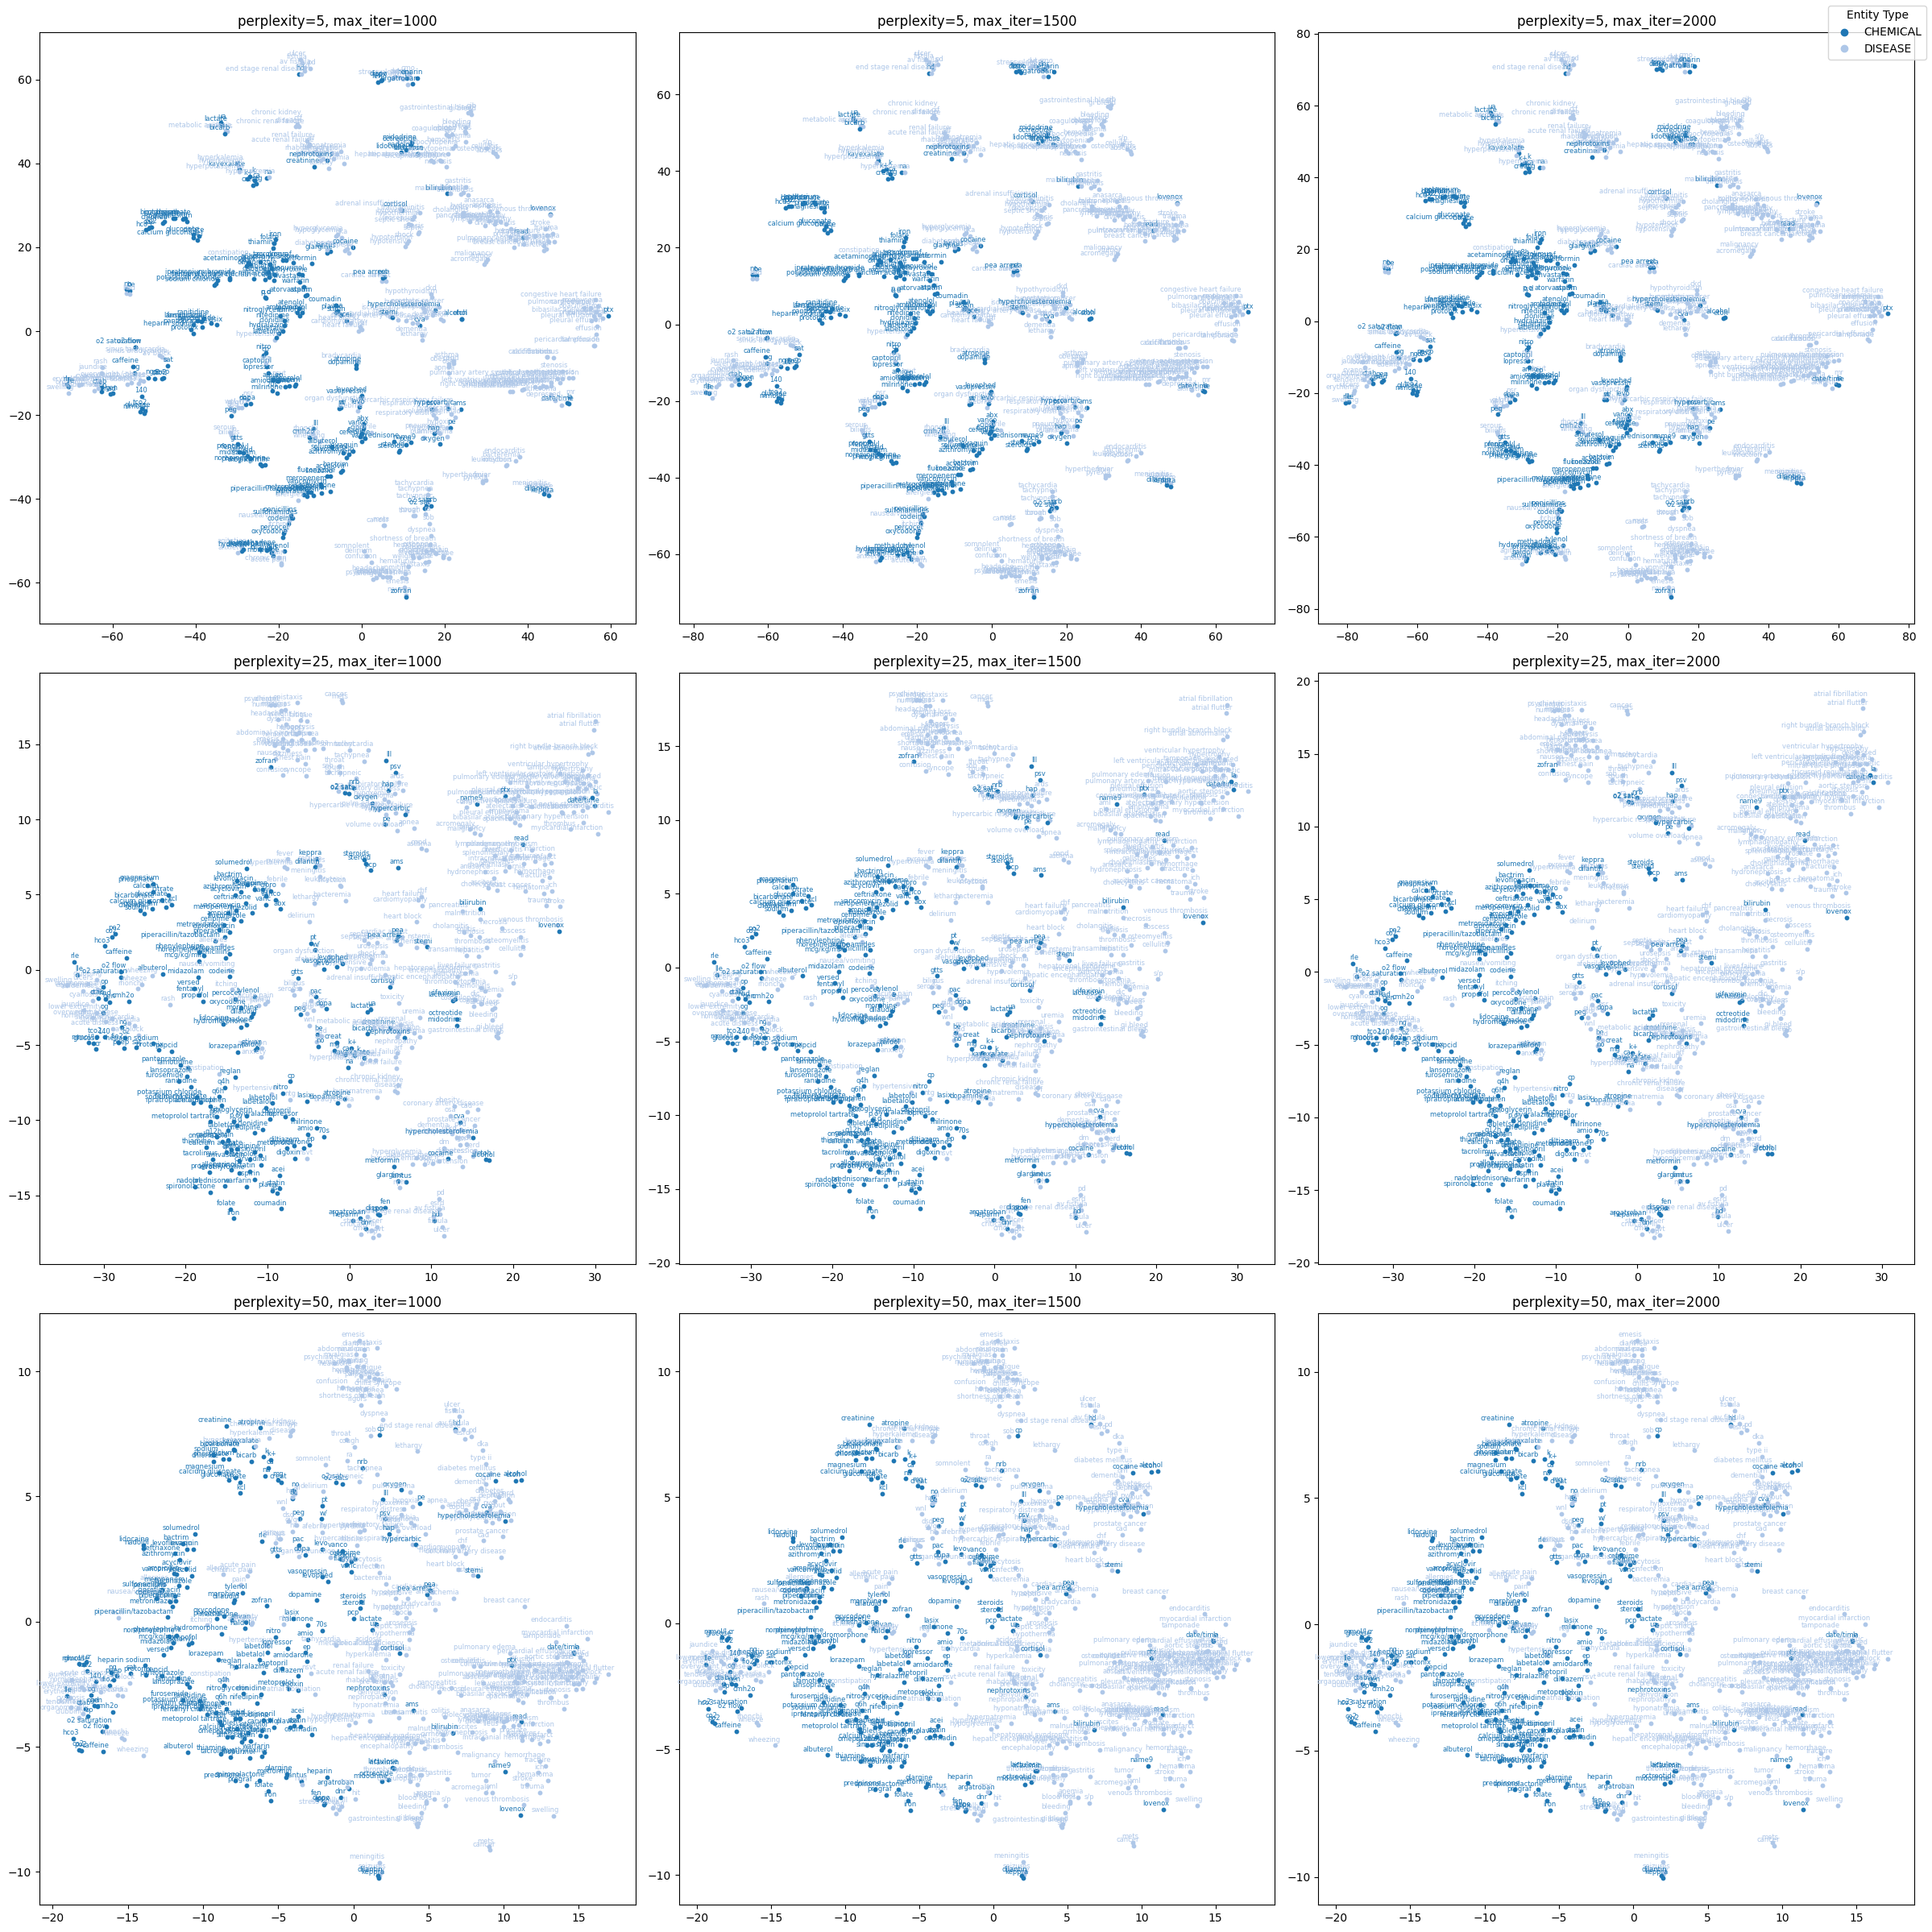

In [96]:
"""
Print plot for the corpus
"""
# Only using top 500 entities, more than that would compromise the value of the plots
vocabs = list(model.wv.key_to_index.keys())[:500]
new_v = np.array(vocabs)

fig, axes = plt.subplots(3, 3, figsize=(24, 24))

handles = tune_tsne_plot(model, new_v, 5, 1000, entity_labels=scispacy_entities, ax=axes[0,0])
handles = tune_tsne_plot(model, new_v, 5, 1500, entity_labels=scispacy_entities, ax=axes[0,1])
handles = tune_tsne_plot(model, new_v, 5, 2000, entity_labels=scispacy_entities, ax=axes[0,2])

handles = tune_tsne_plot(model, new_v, 25, 1000, entity_labels=scispacy_entities, ax=axes[1,0])
handles = tune_tsne_plot(model, new_v, 25, 1500, entity_labels=scispacy_entities, ax=axes[1,1])
handles = tune_tsne_plot(model, new_v, 25, 2000, entity_labels=scispacy_entities, ax=axes[1,2])

handles = tune_tsne_plot(model, new_v, 50, 1000, entity_labels=scispacy_entities, ax=axes[2,0])
handles = tune_tsne_plot(model, new_v, 50, 1500, entity_labels=scispacy_entities, ax=axes[2,1])
handles = tune_tsne_plot(model, new_v, 50, 2000, entity_labels=scispacy_entities, ax=axes[2,2])

fig.legend(handles=handles, title="Entity Type", loc="upper right")
plt.tight_layout()
plt.savefig('scispacy_tsne_tuning.png')
plt.show()

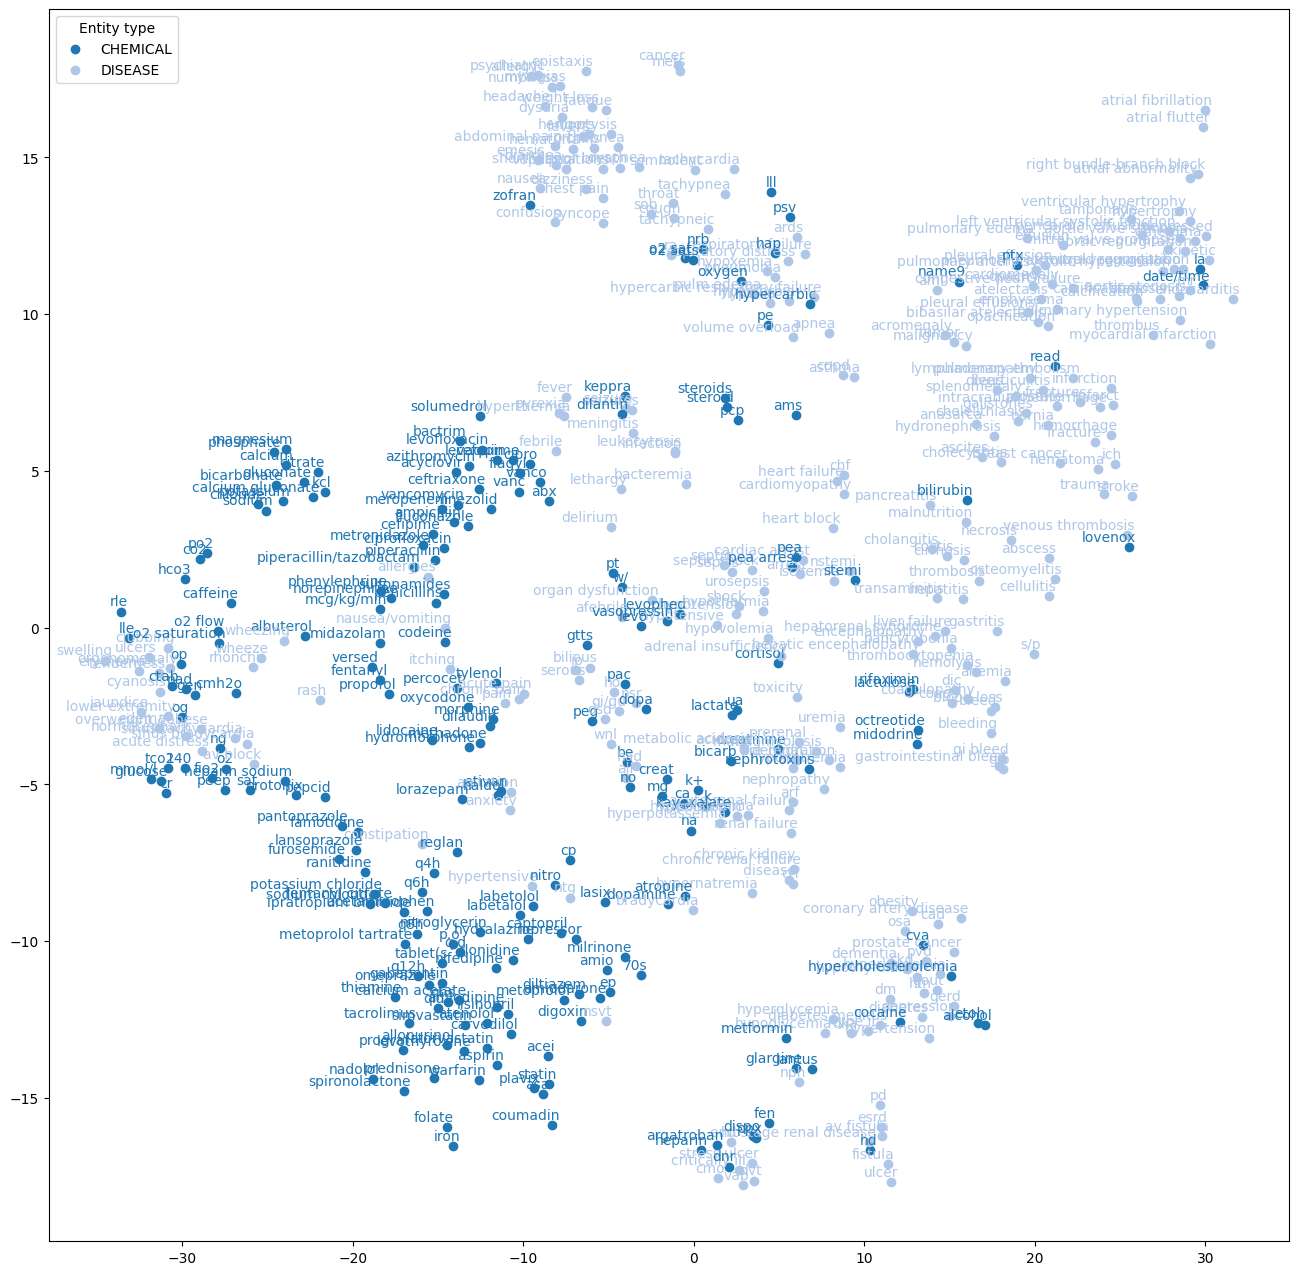

In [97]:
tsne_plot(model, new_v, 25, 1000, "scispacy_tuned_tsne", entity_labels=scispacy_entities)

# **MedSpaCy**

In [98]:
"""
Build corpus of entities and a dict entity text and label.
"""

import os, pickle
from tqdm.auto import tqdm
import medspacy
from medspacy.ner import TargetRule


PE = "medspacy_entities.pkl"
PC = "medspacy_corpus_entities.pkl"
SAMPLE_FRAC = 0.05 # Using a smaller subset as this is very computationally expensive
MAX_CHARS = 20000

# Creating a set of rules for medspacy found in the dataset
TERMS = {
    "PROBLEM": [
        "hyperkalemia", "hyperpotassemia", "hypokalemia", "hyponatremia", "hypernatremia",
        "acute kidney injury", "acute renal failure", "renal failure", "chronic kidney disease",
        "ckd", "esrd", "acidosis", "metabolic acidosis", "diabetic ketoacidosis", "dka",
        "congestive heart failure", "chf", "atrial fibrillation", "arrhythmia", "bradycardia",
        "hypertension", "hypotension", "diabetes", "sepsis", "pneumonia", "rhabdomyolysis",
        "dehydration", "hemolysis", "peaked t waves", "wide qrs",
    ],
    "MEDICATION": [
        "kayexalate", "sodium polystyrene sulfonate", "insulin", "calcium gluconate",
        "calcium chloride", "furosemide", "lasix", "sodium bicarbonate", "albuterol",
        "dextrose", "lisinopril", "spironolactone", "potassium chloride", "heparin",
        "metoprolol", "lovenox",
    ],
    "LAB": [
        "potassium", "creatinine", "bun", "sodium", "bicarbonate", "glucose", "magnesium",
        "calcium", "phosphate", "lactate", "hematocrit", "hemoglobin", "wbc", "troponin",
    ],
    "PROCEDURE": [
        "dialysis", "hemodialysis", "ekg", "ecg", "intubation", "central line", "foley",
    ],
}

if os.path.exists(PE) and os.path.exists(PC):
    medspacy_entities = pickle.load(open(PE, "rb"))
    medspacy_corpus = pickle.load(open(PC, "rb"))
else:
    nlp = medspacy.load()
    target_matcher = nlp.get_pipe("medspacy_target_matcher")
    rules = [TargetRule(term, category)
            for category, terms in TERMS.items()
            for term in terms]
    target_matcher.add(rules) # type: ignore

    text = noteevents_df['text'].dropna().sample(frac=SAMPLE_FRAC, random_state=42)
    text = text.str.slice(0, MAX_CHARS)

    medspacy_entities = {}
    medspacy_corpus = []
    n_total = n_negated = 0

    for doc in tqdm(nlp.pipe(text, batch_size=32, n_process=1), total=len(text), desc="Extracting entities"):
        kept = []

        for e in doc.ents:
            n_total += 1

            # Ignore negated entities
            if e._.is_negated:
                n_negated += 1
                continue
            kept.append(e)

        medspacy_corpus.append([e.text.lower() for e in kept])

        for e in kept:
            medspacy_entities.setdefault(e.text.lower(), e.label_)

    pickle.dump(medspacy_entities, open(PE, "wb"))
    pickle.dump(medspacy_corpus, open(PC, "wb"))

In [99]:
from collections import Counter
import pandas as pd

corpus, ents = medspacy_corpus, medspacy_entities

counts = Counter(e for note in corpus for e in note)
top30 = [(" ".join(e.split()), ents.get(e, "UNKNOWN"), c) for e, c in counts.most_common(30)]

display(pd.DataFrame(top30, columns=["Entity", "Type", "Mentions"], index=range(1, len(top30) + 1)))


,Entity,Type,Mentions
1,insulin,MEDICATION,979
2,wbc,LAB,911
3,renal failure,PROBLEM,871
4,hypotension,PROBLEM,844
5,heparin,MEDICATION,832
6,lasix,MEDICATION,735
7,glucose,LAB,735
8,hypertension,PROBLEM,654
9,pneumonia,PROBLEM,580
10,dialysis,PROCEDURE,572


In [100]:
"""
Train word2vec on the corpus
"""

from gensim.models import Word2Vec

# Removing these entities because it filled the plot with numbers
# skip = {"CARDINAL", "PERCENT", "QUANTITY", "TIME", "DATE", "ORDINAL", "MONEY"}
skip = []

corpus_filtered = [
    [e for e in note if medspacy_entities.get(e, "") not in skip]
    for note in medspacy_corpus
]

model = Word2Vec(corpus_filtered, min_count=5)

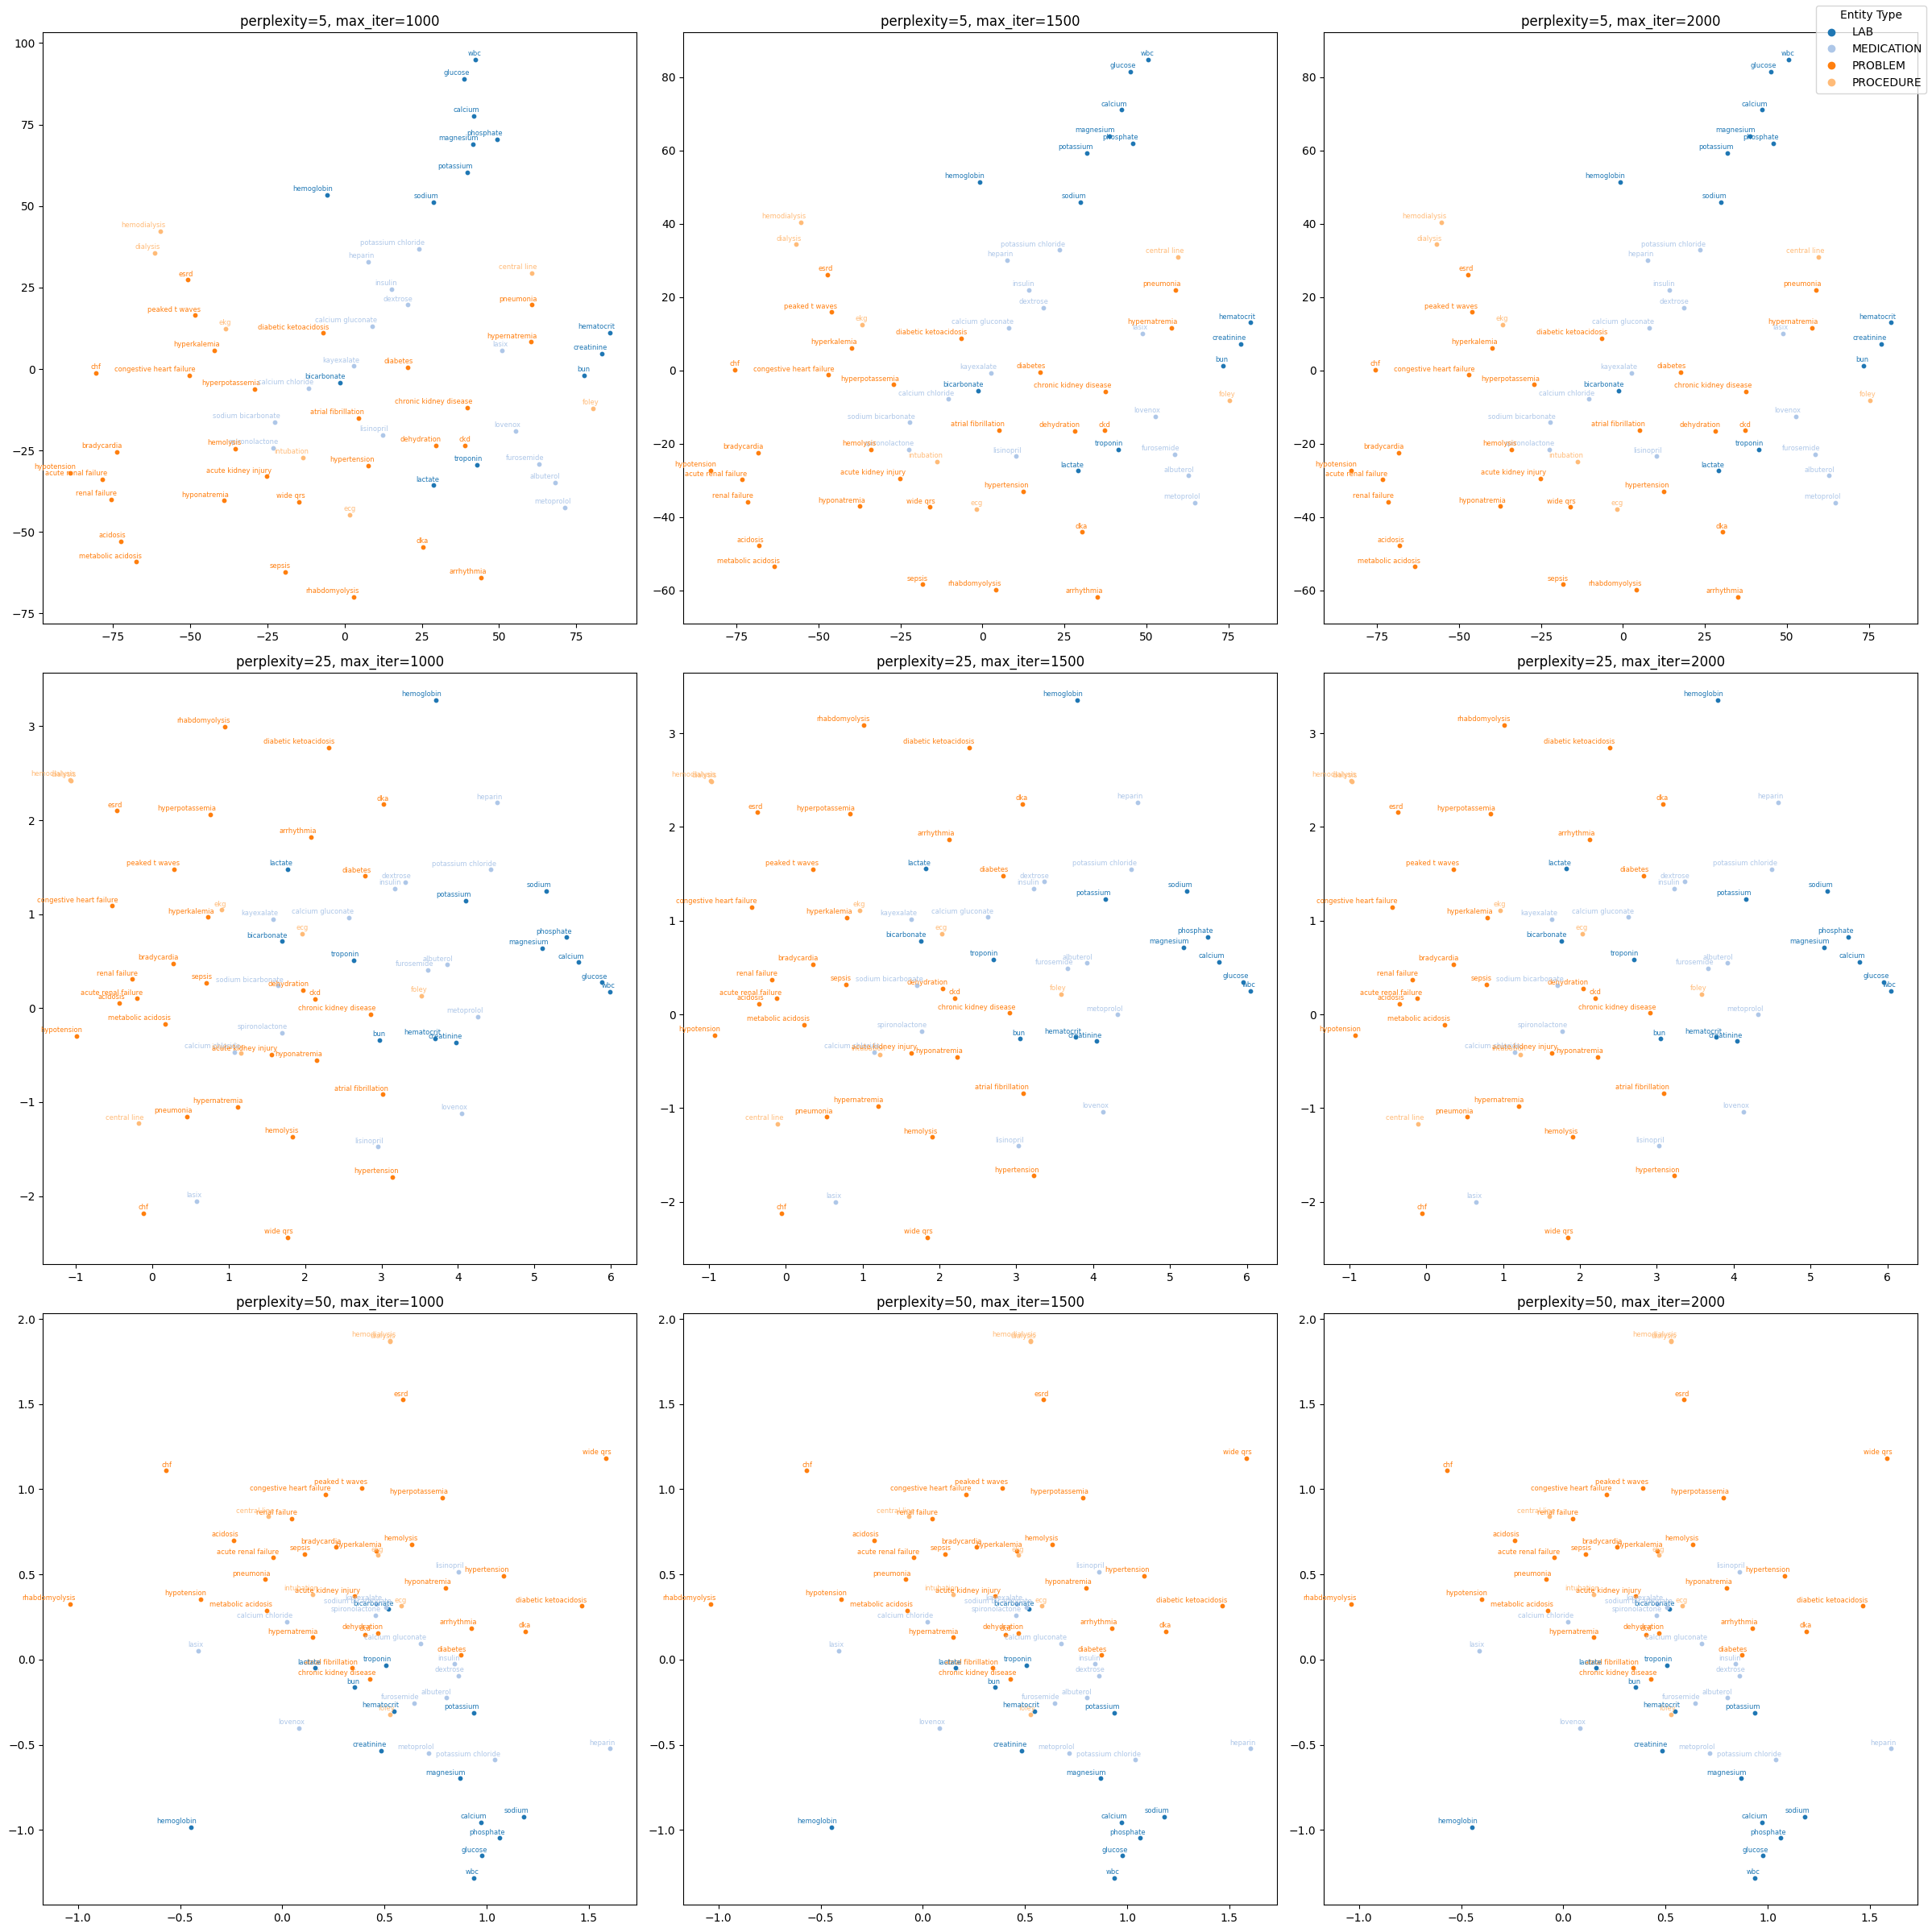

In [101]:
"""
Print plot for the corpus
"""
# Only using top 500 entities, more than that would compromise the value of the plots
vocabs = list(model.wv.key_to_index.keys())[:500]
new_v = np.array(vocabs)

fig, axes = plt.subplots(3, 3, figsize=(24, 24))

handles = tune_tsne_plot(model, new_v, 5, 1000, entity_labels=medspacy_entities, ax=axes[0,0])
handles = tune_tsne_plot(model, new_v, 5, 1500, entity_labels=medspacy_entities, ax=axes[0,1])
handles = tune_tsne_plot(model, new_v, 5, 2000, entity_labels=medspacy_entities, ax=axes[0,2])

handles = tune_tsne_plot(model, new_v, 25, 1000, entity_labels=medspacy_entities, ax=axes[1,0])
handles = tune_tsne_plot(model, new_v, 25, 1500, entity_labels=medspacy_entities, ax=axes[1,1])
handles = tune_tsne_plot(model, new_v, 25, 2000, entity_labels=medspacy_entities, ax=axes[1,2])

handles = tune_tsne_plot(model, new_v, 50, 1000, entity_labels=medspacy_entities, ax=axes[2,0])
handles = tune_tsne_plot(model, new_v, 50, 1500, entity_labels=medspacy_entities, ax=axes[2,1])
handles = tune_tsne_plot(model, new_v, 50, 2000, entity_labels=medspacy_entities, ax=axes[2,2])

fig.legend(handles=handles, title="Entity Type", loc="upper right")
plt.tight_layout()
plt.savefig('medspacy_tsne_tuning.png')
plt.show()

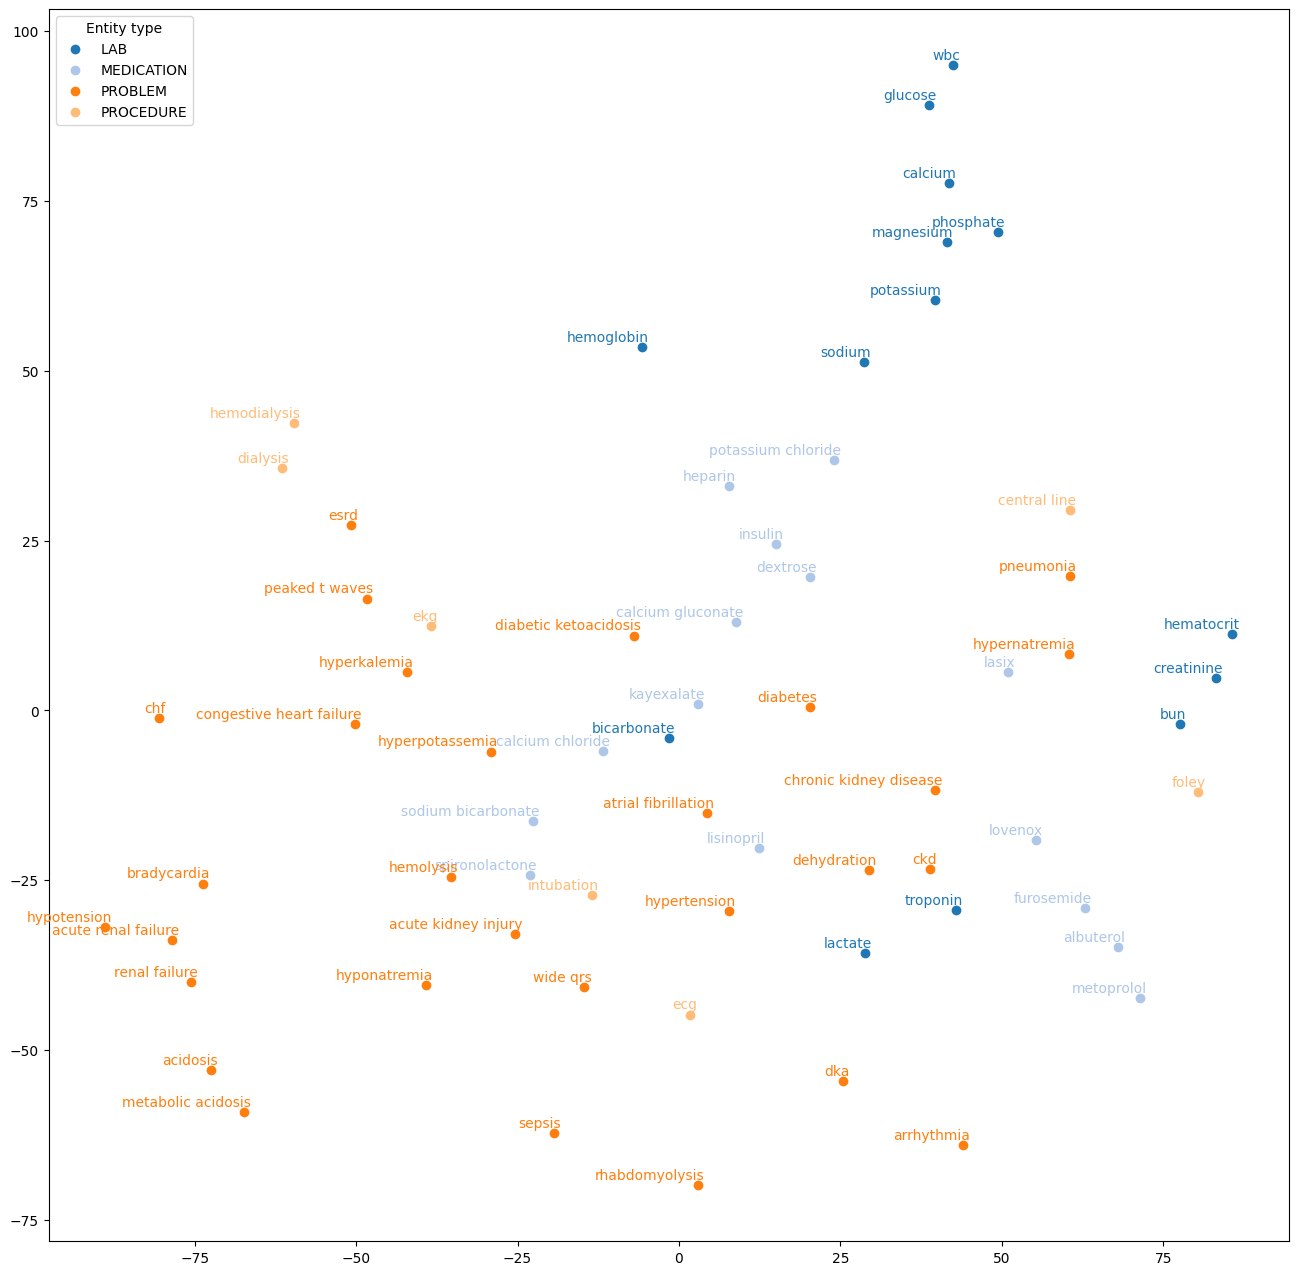

In [102]:
tsne_plot(model, new_v, 5, 1000, "medspacy_tuned_tsne", entity_labels=medspacy_entities)

# **Comparing All 3 Methods**

In [103]:
"""
Compare spaCy, scispaCy and medspaCy 

Evaluating entity stats, word2vec vocab, overlap, similarity
"""

import pandas as pd
from collections import Counter
from itertools import combinations
from gensim.models import Word2Vec

libs = {
    "spaCy":    (spacy_corpus,    spacy_entities),
    "scispaCy": (scispacy_corpus, scispacy_entities),
    "medspaCy": (medspacy_corpus, medspacy_entities),
}

w2v = {name: Word2Vec(corpus, min_count=5, workers=1, seed=23) for name, (corpus, _) in libs.items()}

# Build a summary table for each method
stats = {}
for name, (corpus, ents) in libs.items():
    counts = Counter(e for note in corpus for e in note)
    n_mentions = sum(counts.values())
    n_notes = len(corpus)
    stats[name] = {
        "Notes processed": n_notes,
        "Notes with >=1 entity": sum(1 for note in corpus if note),
        "Total mentions": n_mentions,
        "Unique entities": len(counts),
        "Mentions / note": round(n_mentions / n_notes, 1),
        "Entity types": len(set(ents.values())),
        "Appear only once": sum(1 for c in counts.values() if c == 1),
        "Word2Vec vocab (min_count=5)": len(w2v[name].wv),
        "% appear only once": round(100 * sum(1 for c in counts.values() if c == 1) / len(counts), 1),
    }

summary = pd.DataFrame(stats)   # columns = libraries, rows = metrics
display(summary)

# Entity breakdown per method
for name, (corpus, ents) in libs.items():
    counts = Counter(e for note in corpus for e in note)
    mention_types = Counter()
    unique_types = Counter()
    for e, c in counts.items():
        t = ents.get(e, "UNKNOWN")
        mention_types[t] += c
        unique_types[t] += 1
    df = pd.DataFrame({"Mentions": mention_types, "Unique": unique_types}).fillna(0).astype(int)
    df["% mentions"] = (100 * df["Mentions"] / df["Mentions"].sum()).round(1)
    print(f"\n=== {name}: entity types ===")
    display(df.sort_values("Mentions", ascending=False))

# Top 15 entities
top = {}
for name, (corpus, ents) in libs.items():
    counts = Counter(e for note in corpus for e in note)
    top[name] = [f"{e} ({ents.get(e, '?')}, {c})" for e, c in counts.most_common(15)]
print("\n=== Top 15 entities: text (type, count) ===")
display(pd.DataFrame(top, index=range(1, 16)))

# Overlap between methods
uniq = {name: set(e for note in corpus for e in note) for name, (corpus, _) in libs.items()}
overlap_rows = []
for a, b in combinations(libs, 2):
    inter = uniq[a] & uniq[b]
    union = uniq[a] | uniq[b]
    overlap_rows.append({
        "Pair": f"{a} vs {b}",
        "Shared unique entities": len(inter),
        "% of smaller set shared": round(100 * len(inter) / min(len(uniq[a]), len(uniq[b])), 1),
    })
print("\n=== Overlap of unique entity strings ===")
display(pd.DataFrame(overlap_rows).set_index("Pair"))
print("Shared by all three:", len(uniq["spaCy"] & uniq["scispaCy"] & uniq["medspaCy"]))

# Nearest neighbor exploration
anchors = ["potassium", "hyperkalemia", "hyperpotassemia", "insulin", "dialysis", "furosemide", "creatinine", "heparin"]
print("\n=== Word2Vec most similar (top 5) ===")
for term in anchors:
    print(f"\n'{term}'")
    for name, m in w2v.items():
        if term in m.wv:
            sims = ", ".join(f"{w} ({s:.2f})" for w, s in m.wv.most_similar(term, topn=5))
            print(f"  {name:9s}: {sims}")
        else:
            print(f"  {name:9s}: not in vocab")


,spaCy,scispaCy,medspaCy
Notes processed,14795.0,14795.0,3699.0
Notes with >=1 entity,14643.0,13948.0,2562.0
Total mentions,797483.0,347266.0,18313.0
Unique entities,78861.0,19658.0,67.0
Mentions / note,53.9,23.5,5.0
Entity types,18.0,2.0,4.0
Appear only once,42926.0,10647.0,0.0
Word2Vec vocab (min_count=5),15072.0,4145.0,65.0
% appear only once,54.4,54.2,0.0



=== spaCy: entity types ===


,Mentions,Unique,% mentions
CARDINAL,232509,14360,29.2
ORG,221945,16710,27.8
DATE,104605,19132,13.1
PERSON,73106,7765,9.2
TIME,49292,5185,6.2
GPE,23439,1522,2.9
PERCENT,19588,1714,2.5
QUANTITY,15216,3642,1.9
PRODUCT,12472,1838,1.6
NORP,12029,549,1.5



=== scispaCy: entity types ===


,Mentions,Unique,% mentions
DISEASE,201972,13064,58.2
CHEMICAL,145294,6594,41.8


...


=== Top 15 entities: text (type, count) ===


,spaCy,scispaCy,medspaCy
1,"2 (CARDINAL, 9858)","pain (DISEASE, 6471)","insulin (MEDICATION, 979)"
2,"1 (CARDINAL, 9323)","pt (CHEMICAL, 3544)","wbc (LAB, 911)"
3,"response (ORG, 7761)","lasix (CHEMICAL, 3281)","renal failure (PROBLEM, 871)"
4,"3 (CARDINAL, 6109)","edema (DISEASE, 3260)","hypotension (PROBLEM, 844)"
5,"icu (ORG, 5479)","heparin (CHEMICAL, 3202)","heparin (MEDICATION, 832)"
6,"today (DATE, 5087)","hypotension (DISEASE, 3194)","lasix (MEDICATION, 735)"
7,"5 (CARDINAL, 4694)","allergies (DISEASE, 3046)","glucose (LAB, 735)"
8,"bp (ORG, 4172)","fio2 (CHEMICAL, 2941)","hypertension (PROBLEM, 654)"
9,"po (ORG, 4142)","o2 (CHEMICAL, 2929)","pneumonia (PROBLEM, 580)"
10,"4 (CARDINAL, 3994)","ng (CHEMICAL, 2928)","dialysis (PROCEDURE, 572)"



=== Overlap of unique entity strings ===


,Shared unique entities,% of smaller set shared
Pair,,
spaCy vs scispaCy,3260,16.6
spaCy vs medspaCy,61,91.0
scispaCy vs medspaCy,52,77.6


Shared by all three: 49

=== Word2Vec most similar (top 5) ===

'potassium'
  spaCy    : assessment and plan
   fever (0.92), alcoholic (0.92), hyperpotassemia (0.92), chronic (0.91), assessment and plan
 atrial fibrillation (0.91)
  scispaCy : bicarbonate (0.92), hyperpotassemia (0.86), calcium (0.86), kayexalate (0.84), sodium (0.81)
  medspaCy : magnesium (1.00), bicarbonate (1.00), creatinine (1.00), calcium (1.00), dextrose (1.00)

'hyperkalemia'
  spaCy    : crf (0.86), mg (0.85), anemia (0.85), rf (0.84), cocaine (0.84)
  scispaCy : hyperkalemic (0.89), kayexalate (0.86), nephrotoxins (0.80), hyperpotassemia (0.80), dehydration (0.79)
  medspaCy : kayexalate (1.00), peaked t waves (1.00), sodium bicarbonate (1.00), bicarbonate (1.00), ecg (1.00)

'hyperpotassemia'
  spaCy    : chronic (0.97), control (0.96), hyperthermia (0.96), fuo (0.95), renal failure (0.95)
  scispaCy : dextrose (0.95), kayexalate (0.92), insulin/glucose (0.91), ca gluconate (0.90), hyperkalemic (0.87)
  med

# **Finalize Requirements File**

In [104]:
# Update requirements file
import sys
!{sys.executable} -m pipreqs.pipreqs . --force --scan-notebooks

Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
INFO: Successfully saved requirements file in .\requirements.txt
